In [1]:
import hurricane_net as hn
import datetime
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import json

hurricane_net 2026-06-19 21:53:03,685 - DEBUG - matplotlib - matplotlib data path: /home/hammad/Documents/hurricane-net/venv/lib/python3.14/site-packages/matplotlib/mpl-data
hurricane_net 2026-06-19 21:53:03,691 - DEBUG - matplotlib - CONFIGDIR=/home/hammad/.config/matplotlib
hurricane_net 2026-06-19 21:53:03,706 - DEBUG - matplotlib - interactive is False
hurricane_net 2026-06-19 21:53:03,706 - DEBUG - matplotlib - platform is linux


In [2]:
data = hn.data()

hurricane_net 2026-06-19 21:53:03,727 - INFO - root - Loading data with link for ibtracs.ALL.list.v04r01.csv
hurricane_net 2026-06-19 21:53:52,636 - INFO - root - Loading complete. hn.data.all_storms available
hurricane_net 2026-06-19 21:53:52,637 - INFO - root - hn.data.storms has all available storms.


# Peak Season Forecast with In-Depth Example for the Atlantic Basin

In [3]:
# Load storms from the North Atlantic basin
data.filter('NA')
atlantic_storms = data.storms

hurricane_net 2026-06-19 21:53:52,878 - INFO - root - hn.data.storms set to NA basin.


In [4]:
time_col = 'ISO_TIME' # ISO 8601 format
wind_col = 'WMO_WIND' # In knots
# clean data
df = atlantic_storms
df[time_col] = atlantic_storms[time_col].map(lambda x: datetime.datetime.fromisoformat(x))
df = df[df[wind_col] != ' ']

In [5]:
print(f"Training Data Date Range: {min(df[time_col])} to {max(df[time_col])}")

Training Data Date Range: 1851-06-25 00:00:00 to 2025-11-01 06:00:00


In [6]:
# display example of storms for 2025
storms_2025 = df[df[time_col].map(lambda x: x.year) == 2025]
storms_2025[['SID', time_col, 'NAME', 'NATURE', 'LAT', 'LON', wind_col]]

,SID,ISO_TIME,NAME,NATURE,LAT,LON,WMO_WIND
719484,2025173N30302,2025-06-22 00:00:00,ANDREA,DS,30.0,-57.6,20
719486,2025173N30302,2025-06-22 06:00:00,ANDREA,DS,30.5,-57.6,20
719488,2025173N30302,2025-06-22 12:00:00,ANDREA,DS,31.0,-57.6,25
719490,2025173N30302,2025-06-22 18:00:00,ANDREA,DS,31.5,-57.4,25
719492,2025173N30302,2025-06-23 00:00:00,ANDREA,DS,32.0,-57.0,30
...,...,...,...,...,...,...,...
722671,2025294N14290,2025-10-31 06:00:00,MELISSA,TS,34.5,-65.5,75
722673,2025294N14290,2025-10-31 12:00:00,MELISSA,ET,37.7,-62.1,75
722675,2025294N14290,2025-10-31 18:00:00,MELISSA,ET,40.6,-58.9,70
722677,2025294N14290,2025-11-01 00:00:00,MELISSA,ET,43.7,-56.0,70


In [7]:
# filter to entries where there was a severe storm, Category 3 (Saffir-Simpson scale) or higher
threshold = 96 #kt, https://www.nhc.noaa.gov/aboutsshws.php
severe_df = df[df[wind_col].astype('int') > threshold]
# The data quality improved since 1970 and based on that we can use this optional filter
# severe_df = severe_df[severe_df['entry_time'].map(lambda x: x.year) > 1970]
severe_df.sample(5)

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
589741,2004238N11325,2004,58,NA,NA,FRANCES,2004-08-27 18:00:00,TS,15.4,-49.3,...,,,,,,,,,9,310
78833,1900239N15318,1900,22,NA,GM,UNNAMED,1900-09-09 02:00:00,TS,29.1,-95.1,...,,,,,,,,,13,305
62384,1893228N18340,1893,28,NA,NA,UNNAMED,1893-08-23 12:00:00,TS,22.2,-61.7,...,,,,,,,,,12,275
590404,2004247N10332,2004,66,NA,GM,IVAN,2004-09-15 00:00:00,TS,24.7,-87.0,...,,,,,,,,,10,335
675440,2018242N13343,2018,71,NA,NA,FLORENCE,2018-09-11 00:00:00,TS,25.6,-61.8,...,,,,12,240,150,90,210,12,290


hurricane_net 2026-06-19 21:53:53,370 - DEBUG - matplotlib - CACHEDIR=/home/hammad/.cache/matplotlib
hurricane_net 2026-06-19 21:53:53,375 - DEBUG - matplotlib.font_manager - Using fontManager instance from /home/hammad/.cache/matplotlib/fontlist-v3.11.0.json
hurricane_net 2026-06-19 21:53:53,615 - DEBUG - matplotlib.pyplot - Loaded backend module://matplotlib_inline.backend_inline version unknown.
hurricane_net 2026-06-19 21:53:53,712 - DEBUG - matplotlib.pyplot - Loaded backend module://matplotlib_inline.backend_inline version unknown.
hurricane_net 2026-06-19 21:53:53,718 - DEBUG - matplotlib.font_manager - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
hurricane_net 2026-06-19 21:53:53,719 - DEBUG - matplotlib.font_manager - findfont: score(FontEntry(fname='/home/hammad/Documents/hurricane-net/venv/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBolIta.ttf', index=0, name='STIXNonUnicode', style='italic', vari

<Axes: xlabel='Calendar Day Number', ylabel='Frequency'>

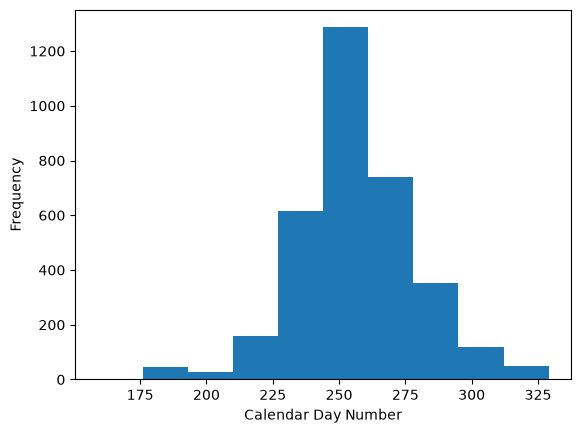

In [8]:
times = severe_df[time_col].map(lambda x: x.timetuple().tm_yday)
times.plot.hist(xlabel="Calendar Day Number")

In [9]:
times.describe()

count    3391.000000
mean      256.027131
std        22.420739
min       159.000000
25%       243.500000
50%       254.000000
75%       270.000000
max       329.000000
Name: ISO_TIME, dtype: float64

In [10]:
def day_count_text(day_count, formatter = '%B %-d'):
  timeline = datetime.datetime(2025, 1, 1) + datetime.timedelta(days = day_count - 1)
  return timeline.strftime(formatter)

In [11]:
# 90% confidence interval
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tstd.html#scipy.stats.tstd
# Calculate statistics like mean and standard deviation
times_mean, times_std = np.mean(times), stats.tstd(times)
print(f"Mean: {round(times_mean)} ({day_count_text(round(times_mean))})")
print(f"Standard Deviation: {round(times_std)} days")

# calculate interval
times_interval = stats.norm.interval(confidence=0.90, loc=times_mean, scale=times_std)
# find start and end of interval and display
times_ci_start = round(times_interval[0])
times_ci_end = round(times_interval[1])
print(f"90% Confidence Interval: {day_count_text(times_ci_start)} to {day_count_text(times_ci_end)}")


Mean: 256 (September 13)
Standard Deviation: 22 days
90% Confidence Interval: August 7 to October 20


In [12]:
lower_bound = 152 # June 1st
upper_bound = 334 # November 30th
scale = upper_bound - lower_bound

# Perform the Kolmogorov-Smirnov test:
# The 'uniform' string or stats.uniform(loc=lower_bound, scale=scale).cdf can be used
statistic, p_value = stats.kstest(times, 'uniform', args=(lower_bound, scale))

print(f"KS Statistic: {statistic}")
print(f"P-value: {p_value}")

# Interpret the results:
# A high p-value (typically > 0.05) suggests that you cannot reject the null hypothesis
# that the sample comes from a uniform distribution.
if p_value > 0.05:
    print("The sample appears to be uniformly distributed.")
else:
    print("The sample does not appear to be uniformly distributed.")

KS Statistic: 0.3440749754521503
P-value: 0.0
The sample does not appear to be uniformly distributed.


# Global Calculation
Utilizing the example above, we can loop through all other basins and calculate a forecast based on the hurricane_net data.

In [23]:
def peak_season_forecast(basin, data, col='BASIN', graph=False):
    '''
    Parameters
    ----------
    basin
      The basin identifier in the IBTrACS
    data
      The loaded data from hurricane_net
    col
      The column name for the basin
    graph
      Saves out a graph for the basin the current directory with
      the filename basin_peak_season.png
    
    Returns
    -------
    [ basin : {
        training_range_start
        training_range_end
        mean
        mean_day
        stdev
        ci_start
        ci_end
        ks_stat
        ks_stat_p_value
        uniform_dist_bool
    } ... ]
    '''
    # initialize data
    result = {'id': basin, 'col': col}
    name = False
    if col == 'BASIN':
        name = basins[basin]
    elif col == 'SUBBASIN':
        name = sub_basins[basin]
    result['name'] = name
    storms = data[data[col] == basin]
    time_col = 'ISO_TIME' # ISO 8601 format
    wind_col = 'WMO_WIND' # In knots
    
    # clean data
    df = storms
    df = df[df[wind_col] != ' ']
    df = df[df[time_col] != ' ']
    df[time_col] = storms[time_col].map(lambda x: datetime.datetime.fromisoformat(x) if type(x) == str else x)
    result['training_range_start'] = min(df[time_col]).isoformat()
    result['training_range_end'] = max(df[time_col]).isoformat()
    print(name)
    
    # filter to entries where there was a severe storm, Category 3 (Saffir-Simpson scale) or higher
    threshold = 96 #kt, https://www.nhc.noaa.gov/aboutsshws.php
    severe_df = df[df[wind_col].astype('int') > threshold]
    times = severe_df[time_col].map(lambda x: x.timetuple().tm_yday)
    print(f"Count of severe storm samples: {len(times)} out of {len(df)} cleaned and {len(storms)} total")
    result.update({'count': len(storms), 'count_clean': len(df), 'count_severe': len(times)})

    # calendar day --> month and day (non-leap year)
    def day_count_text(day_count, formatter = '%B %-d', current_year=2026):
        timeline = datetime.datetime(current_year, 1, 1) + datetime.timedelta(days = day_count - 1)
        return timeline.strftime(formatter)

    # 90% confidence interval
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tstd.html#scipy.stats.tstd
    # Calculate statistics like mean and standard deviation
    if len(times) < 40: # not enough samples
        print(f'Not enough samples for {basin} at {len(times)}')
        result.update({'error': f'Sample size is less than threshold at {len(times)}'})
        return result
    times_mean, times_std = np.mean(times), stats.tstd(times)
    result['mean'] = round(times_mean)
    result['mean_day'] = day_count_text(round(times_mean))
    result['stdev'] = round(times_std)
    # calculate interval
    times_interval = stats.norm.interval(confidence=0.95, loc=times_mean, scale=times_std)
    print(times_interval)
    result['ci'] = times_interval
    # find start and end of interval and display
    times_ci_start = round(times_interval[0])
    times_ci_end = round(times_interval[1])
    if times_ci_end - times_ci_start > 365 : # confidence interval is longer than a year
        result.update({'error': f'Confidence interval larger than a calendar year'})
        return result
    # clip confidence interval by possible calendar days
    result['ci_start'] = day_count_text(max(1, times_ci_start))
    result['ci_end'] = day_count_text(min(365, times_ci_end))
    print(f"{basin} 95% Confidence Interval: {day_count_text(times_ci_start)} to {day_count_text(times_ci_end)}")
    
    # Perform the Kolmogorov-Smirnov test:
    # The 'uniform' string or stats.uniform(loc=lower_bound, scale=scale).cdf can be used
    lower_bound = 152 # First day of hurricane season: June 1st
    upper_bound = 334 # Last day of hurricane season: November 30th
    scale = upper_bound - lower_bound
    statistic, p_value = stats.kstest(times, 'uniform', args=(lower_bound, scale))
    result['ks_stat'] = statistic
    result['ks_stat_p_value'] = p_value
    # Interpret the results:
    # A high p-value (typically > 0.05) suggests that you cannot reject the null hypothesis
    # that the sample comes from a uniform distribution.
    if p_value > 0.05:
        print("The sample appears to be uniformly distributed.")
        result['uniform_dis_bool'] =  True
    else:
        print("The sample does not appear to be uniformly distributed.")
        result['uniform_dis_bool'] = False

    # Output graph
    if graph:
        ax = times.plot.hist(xlabel="Calendar Day Number",
                            title=f'Daily Counts of Active Category 3+ storms in the {name if name else basin} (Sub)Basin')
        ax.figure.savefig(
            f"img/{basin if not name else name}_severe_storm_calendar_day.png",
            dpi=300,
            bbox_inches='tight')
        ax.clear()

    # return statistics
    return result

In [24]:
basins = {
    'NA' : 'North Atlantic',
    'EP' : 'Eastern North Pacific',
    'WP' : 'Western North Pacific',
    'NI' : 'North Indian',
    'SI' : 'South Indian',
    'SP' : 'Southern Pacific',
    'SA' : 'South Atlantic' # not enough data
}
sub_basins = {
    #MM - missing - no sub basin for this basin (no subbasins provided for WP, SI)
    'CS' : 'Caribbean Sea',
    'GM' : 'Gulf of America',
    'CP' : 'Central Pacific',
    'BB' : 'Bay of Bengal',
    'AS' : 'Arabian Sea',
    'WA' : 'Western Australia',
    'EA' : 'Eastern Australia',
}

hurricane_net 2026-06-19 21:57:57,590 - INFO - root - hn.data.storms has all available storms.
North Atlantic
Count of severe storm samples: 3391 out of 55422 cleaned and 126461 total
(np.float64(212.0832900475535), np.float64(299.970971232305))
NA 95% Confidence Interval: July 31 to October 27
The sample does not appear to be uniformly distributed.
hurricane_net 2026-06-19 21:57:58,507 - INFO - root - hn.data.storms has all available storms.
Eastern North Pacific
Count of severe storm samples: 1954 out of 31687 cleaned and 65278 total
(np.float64(158.2643762013519), np.float64(309.46745593784976))
EP 95% Confidence Interval: June 7 to November 5
The sample does not appear to be uniformly distributed.
hurricane_net 2026-06-19 21:57:59,119 - INFO - root - hn.data.storms has all available storms.
Western North Pacific
Count of severe storm samples: 1287 out of 28764 cleaned and 242337 total
(np.float64(150.52315515810346), np.float64(366.57241593746767))
WP 95% Confidence Interval: May 3

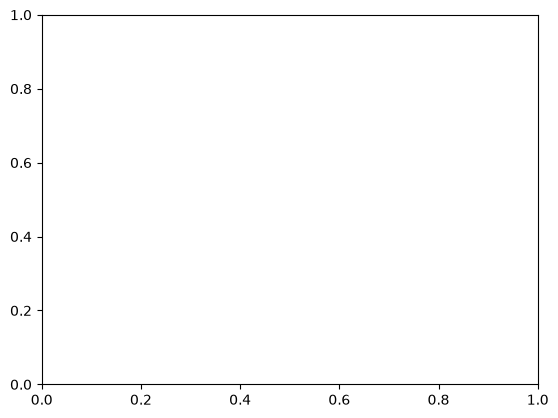

In [25]:
results = []
for basin in basins:
    data.filter('all')
    result = peak_season_forecast(basin, data.storms, graph=True)
    results.append(result)
for sb in sub_basins:
    data.filter('all')
    result = peak_season_forecast(sb, data.storms, col='SUBBASIN', graph=True)
    results.append(result)
df = pd.DataFrame(results)

In [26]:
col_order = ['name', 'ci_start', 'ci_end']
df = df[col_order + [c for c in df.columns if c not in col_order]]
df.to_csv('data/peak_severe_season.csv')

In [27]:
df

,name,ci_start,ci_end,id,col,training_range_start,training_range_end,count,count_clean,count_severe,mean,mean_day,stdev,ci,ks_stat,ks_stat_p_value,uniform_dis_bool,error
0,North Atlantic,July 31,October 27,NA,BASIN,1851-06-25T00:00:00,2025-11-01T06:00:00,126461,55422,3391,256.0,September 13,22.0,"(212.0832900475535, 299.970971232305)",0.344075,0.000000e+00,False,NaN
1,Eastern North Pacific,June 7,November 5,EP,BASIN,1876-10-04T12:00:00,2025-10-29T18:00:00,65278,31687,1954,234.0,August 22,39.0,"(158.2643762013519, 309.46745593784976)",0.179137,2.488870e-55,False,NaN
2,Western North Pacific,May 31,December 31,WP,BASIN,1959-09-08T00:00:00,2026-02-05T18:00:00,242337,28764,1287,259.0,September 16,55.0,"(150.52315515810346, 366.57241593746767)",0.208181,2.103883e-49,False,NaN
3,North Indian,February 22,December 31,NI,BASIN,1982-05-01T03:00:00,2024-12-21T06:00:00,57596,6773,237,223.0,August 11,87.0,"(52.94653123266298, 393.81296243822305)",0.454815,2.584525e-45,False,NaN
4,South Indian,NaN,NaN,SI,BASIN,1973-01-10T01:00:00,2025-04-23T00:00:00,164405,31779,939,122.0,May 2,115.0,"(-103.28985735133672, 346.7509862118266)",NaN,NaN,NaN,Confidence interval larger than a calendar year
5,Southern Pacific,NaN,NaN,SP,BASIN,1968-04-04T12:00:00,2025-05-12T12:00:00,68415,14033,394,89.0,March 30,97.0,"(-101.58553545929932, 279.93578926640595)",NaN,NaN,NaN,Confidence interval larger than a calendar year
6,South Atlantic,NaN,NaN,SA,BASIN,2004-03-25T18:00:00,2011-03-16T18:00:00,119,61,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sample size is less than threshold at 0
7,Caribbean Sea,July 21,November 23,CS,SUBBASIN,1851-07-10T12:00:00,2025-10-29T07:20:00,15627,7010,640,264.0,September 21,32.0,"(201.95004767191742, 326.5187023280826)",0.306696,6.136342e-54,False,NaN
8,Gulf of America,July 27,October 28,GM,SUBBASIN,1851-06-25T00:00:00,2025-06-30T02:00:00,13765,6439,524,254.0,September 11,24.0,"(208.34745565530423, 300.56094129126063)",0.337136,1.255989e-53,False,NaN
9,Central Pacific,June 27,October 19,CP,SUBBASIN,1950-08-12T00:00:00,2025-09-11T00:00:00,11372,5049,370,235.0,August 23,29.0,"(177.74559131678126, 292.4219762507863)",0.263439,3.767018e-23,False,NaN
